# 🎬 Movie Performance Analysis

## Data Analytics Portfolio Project

This project analyzes movie performance using Python, Pandas, SQL, and data visualization.

The analysis explores the factors associated with movie financial success, including:

- Budget and profitability
- Movie genres
- Audience ratings
- Popularity
- Directors and cast
- Movie performance over time

The goal is to identify patterns and insights that help explain which characteristics are associated with higher movie revenue and profit.

### Tools Used
- Python
- Pandas
- Matplotlib
- SQLite
- SQL
- Jupyter Notebook

## 1. Data Loading & Initial Exploration

I started by loading the movie and credits datasets and checking their structure before making any transformations.

At this stage, I looked at:

- Dataset dimensions and available columns
- Data types
- Missing values
- Zero values in budget and revenue
- A sample of the movie records

This helped me understand the main data quality issues before moving into the cleaning stage.


In [8]:
import pandas as pd
import numpy as np

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [9]:
movies = pd.read_csv("../data/tmdb_5000_movies.csv")
credits = pd.read_csv("../data/tmdb_5000_credits.csv")

print("Movies dataset:", movies.shape)
print("Credits dataset:", credits.shape)

Movies dataset: (4803, 20)
Credits dataset: (4803, 4)


In [10]:
movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [11]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status                4803 non-n

In [12]:
movies.isnull().sum().sort_values(ascending=False)

homepage                3091
tagline                  844
overview                   3
runtime                    2
release_date               1
id                         0
budget                     0
genres                     0
original_title             0
popularity                 0
original_language          0
keywords                   0
production_countries       0
production_companies       0
spoken_languages           0
revenue                    0
status                     0
title                      0
vote_average               0
vote_count                 0
dtype: int64

In [13]:
print("Movies with zero budget:", (movies["budget"] == 0).sum())
print("Movies with zero revenue:", (movies["revenue"] == 0).sum())

Movies with zero budget: 1037
Movies with zero revenue: 1427


In [14]:
movies["release_date"] = pd.to_datetime(
    movies["release_date"],
    errors="coerce"
)

movies["release_year"] = movies["release_date"].dt.year

print(movies[["release_date", "release_year"]].head())

  release_date  release_year
0   2009-12-10        2009.0
1   2007-05-19        2007.0
2   2015-10-26        2015.0
3   2012-07-16        2012.0
4   2012-03-07        2012.0


## 2. Data Cleaning & Feature Engineering

The datasets were cleaned and transformed to prepare them for reliable analysis.

Key preparation steps included:

- Handling missing and invalid values
- Converting relevant columns to appropriate data types
- Extracting movie genres from structured data
- Extracting director and cast information
- Merging movie and credits data
- Creating financial metrics such as profit and ROI
- Creating analytical categories for ratings, budgets, and popularity
- Preparing the final cleaned dataset for SQL analysis

In [15]:
import ast

def extract_names(value):
    try:
        items = ast.literal_eval(value)
        return [item["name"] for item in items]
    except:
        return []

movies["genres_list"] = movies["genres"].apply(extract_names)

movies[["title", "genres", "genres_list"]].head()

,title,genres,genres_list
0,Avatar,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[Action, Adventure, Fantasy, Science Fiction]"
1,Pirates of the Caribbean: At World's End,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[Adventure, Fantasy, Action]"
2,Spectre,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[Action, Adventure, Crime]"
3,The Dark Knight Rises,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[Action, Crime, Drama, Thriller]"
4,John Carter,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[Action, Adventure, Science Fiction]"


In [16]:
financial_movies = movies[
    (movies["budget"] > 0) &
    (movies["revenue"] > 0)
].copy()

financial_movies["profit"] = (
    financial_movies["revenue"] - financial_movies["budget"]
)

financial_movies["roi"] = (
    financial_movies["profit"] / financial_movies["budget"]
) * 100

print("Movies with valid financial data:", len(financial_movies))

financial_movies[
    ["title", "budget", "revenue", "profit", "roi"]
].head()

Movies with valid financial data: 3229


,title,budget,revenue,profit,roi
0,Avatar,237000000,2787965087,2550965087,1076.356577
1,Pirates of the Caribbean: At World's End,300000000,961000000,661000000,220.333333
2,Spectre,245000000,880674609,635674609,259.459024
3,The Dark Knight Rises,250000000,1084939099,834939099,333.975640
4,John Carter,260000000,284139100,24139100,9.284269


In [17]:
top_profit = financial_movies.sort_values(
    "profit",
    ascending=False
)

top_profit[
    ["title", "budget", "revenue", "profit", "roi"]
].head(10)

,title,budget,revenue,profit,roi
0,Avatar,237000000,2787965087,2550965087,1076.356577
25,Titanic,200000000,1845034188,1645034188,822.517094
28,Jurassic World,150000000,1513528810,1363528810,909.019207
44,Furious 7,190000000,1506249360,1316249360,692.762821
16,The Avengers,220000000,1519557910,1299557910,590.708141
7,Avengers: Age of Ultron,280000000,1405403694,1125403694,401.929891
124,Frozen,150000000,1274219009,1124219009,749.479339
546,Minions,74000000,1156730962,1082730962,1463.149949
329,The Lord of the Rings: The Return of the King,94000000,1118888979,1024888979,1090.307424
31,Iron Man 3,200000000,1215439994,1015439994,507.719997


In [18]:
top_roi_raw = financial_movies.sort_values(
    "roi",
    ascending=False
)

top_roi_raw[
    ["title", "budget", "revenue", "profit", "roi"]
].head(15)

,title,budget,revenue,profit,roi
4238,Modern Times,1,8500000,8499999,8.499999e+08
3137,Nurse 3-D,10,10000000,9999990,9.999990e+07
4577,Paranormal Activity,15000,193355800,193340800,1.288939e+06
4582,Tarnation,218,1162014,1161796,5.329339e+05
4496,The Blair Witch Project,60000,248000000,247940000,4.132333e+05
4724,Eraserhead,10000,7000000,6990000,6.990000e+04
4788,Pink Flamingos,12000,6000000,5988000,4.990000e+04
4742,Super Size Me,65000,28575078,28510078,4.386166e+04
4723,The Gallows,100000,42664410,42564410,4.256441e+04
4514,Open Water,130000,54667954,54537954,4.195227e+04


In [19]:
roi_movies = financial_movies[
    financial_movies["budget"] >= 10000
].copy()

top_roi = roi_movies.sort_values(
    "roi",
    ascending=False
)

top_roi[
    ["title", "budget", "revenue", "profit", "roi"]
].head(15)

,title,budget,revenue,profit,roi
4577,Paranormal Activity,15000,193355800,193340800,1.288939e+06
4496,The Blair Witch Project,60000,248000000,247940000,4.132333e+05
4724,Eraserhead,10000,7000000,6990000,6.990000e+04
4788,Pink Flamingos,12000,6000000,5988000,4.990000e+04
4742,Super Size Me,65000,28575078,28510078,4.386166e+04
4723,The Gallows,100000,42664410,42564410,4.256441e+04
4514,Open Water,130000,54667954,54537954,4.195227e+04
3159,The Texas Chain Saw Massacre,85000,30859000,30774000,3.620471e+04
4441,Bambi,858000,267447150,266589150,3.107100e+04
4668,The Stewardesses,100000,27000000,26900000,2.690000e+04


In [20]:
genre_analysis = roi_movies.explode("genres_list")

genre_analysis[
    ["title", "genres_list", "budget", "revenue", "profit", "roi"]
].head(10)

,title,genres_list,budget,revenue,profit,roi
0,Avatar,Action,237000000,2787965087,2550965087,1076.356577
0,Avatar,Adventure,237000000,2787965087,2550965087,1076.356577
0,Avatar,Fantasy,237000000,2787965087,2550965087,1076.356577
0,Avatar,Science Fiction,237000000,2787965087,2550965087,1076.356577
1,Pirates of the Caribbean: At World's End,Adventure,300000000,961000000,661000000,220.333333
1,Pirates of the Caribbean: At World's End,Fantasy,300000000,961000000,661000000,220.333333
1,Pirates of the Caribbean: At World's End,Action,300000000,961000000,661000000,220.333333
2,Spectre,Action,245000000,880674609,635674609,259.459024
2,Spectre,Adventure,245000000,880674609,635674609,259.459024
2,Spectre,Crime,245000000,880674609,635674609,259.459024


In [21]:
genre_performance = (
    genre_analysis
    .groupby("genres_list")
    .agg(
        movie_count=("title", "count"),
        median_roi=("roi", "median"),
        average_profit=("profit", "mean"),
        average_revenue=("revenue", "mean"),
        average_rating=("vote_average", "mean"),
        average_popularity=("popularity", "mean")
    )
    .sort_values("median_roi", ascending=False)
    .round(2)
)

genre_performance

,movie_count,median_roi,average_profit,average_revenue,average_rating,average_popularity
genres_list,,,,,,
Music,111,212.30,5.509401e+07,7.906381e+07,6.53,17.91
Horror,329,189.73,4.756931e+07,6.831440e+07,5.90,24.81
Animation,186,178.73,2.002207e+08,2.819165e+08,6.44,46.75
Documentary,37,172.72,2.092843e+07,2.649789e+07,6.82,6.48
Family,364,153.15,1.580211e+08,2.264503e+08,6.19,36.48
Adventure,660,138.67,1.709728e+08,2.479817e+08,6.24,45.53
Romance,570,138.17,6.471397e+07,9.321121e+07,6.35,21.60
Comedy,1104,130.72,7.270928e+07,1.090612e+08,6.08,24.66
Science Fiction,429,122.68,1.265430e+08,1.896499e+08,6.16,43.41


In [22]:
financial_movies[
    ["budget", "revenue", "profit", "roi", "vote_average", "popularity"]
].corr().round(2)

,budget,revenue,profit,roi,vote_average,popularity
budget,1.00,0.71,0.55,-0.02,-0.03,0.43
revenue,0.71,1.00,0.98,-0.01,0.19,0.60
profit,0.55,0.98,1.00,-0.01,0.23,0.59
roi,-0.02,-0.01,-0.01,1.00,0.03,-0.00
vote_average,-0.03,0.19,0.23,0.03,1.00,0.29
popularity,0.43,0.60,0.59,-0.00,0.29,1.00


In [23]:
financial_movies["budget_category"] = pd.cut(
    financial_movies["budget"],
    bins=[0, 10_000_000, 50_000_000, 100_000_000, float("inf")],
    labels=[
        "Low Budget",
        "Medium Budget",
        "High Budget",
        "Blockbuster"
    ]
)

budget_performance = (
    financial_movies
    .groupby("budget_category", observed=True)
    .agg(
        movie_count=("title", "count"),
        median_roi=("roi", "median"),
        average_profit=("profit", "mean"),
        average_revenue=("revenue", "mean"),
        average_rating=("vote_average", "mean")
    )
    .round(2)
)

budget_performance

,movie_count,median_roi,average_profit,average_revenue,average_rating
budget_category,,,,,
Low Budget,805,243.55,2.493736e+07,2.947909e+07,6.51
Medium Budget,1567,108.55,5.347095e+07,8.064808e+07,6.24
High Budget,579,99.02,1.111265e+08,1.835100e+08,6.19
Blockbuster,278,176.02,3.309874e+08,4.860971e+08,6.39


In [24]:
financial_movies["rating_category"] = pd.cut(
    financial_movies["vote_average"],
    bins=[0, 5, 6, 7, 8, 10],
    labels=[
        "Below 5",
        "5-6",
        "6-7",
        "7-8",
        "8+"
    ]
)

rating_performance = (
    financial_movies
    .groupby("rating_category", observed=True)
    .agg(
        movie_count=("title", "count"),
        average_profit=("profit", "mean"),
        median_roi=("roi", "median"),
        average_revenue=("revenue", "mean"),
        average_popularity=("popularity", "mean")
    )
    .round(2)
)

rating_performance

,movie_count,average_profit,median_roi,average_revenue,average_popularity
rating_category,,,,,
Below 5,241,1.094335e+07,-2.00,4.440385e+07,12.09
5-6,941,5.324815e+07,81.94,9.872201e+07,22.08
6-7,1408,8.450320e+07,139.24,1.250035e+08,28.11
7-8,599,1.349490e+08,312.28,1.720854e+08,44.29
8+,38,2.016923e+08,466.52,2.318596e+08,103.85


In [25]:
credits.head()

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [26]:
credits.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   movie_id  4803 non-null   int64
 1   title     4803 non-null   str  
 2   cast      4803 non-null   str  
 3   crew      4803 non-null   str  
dtypes: int64(1), str(3)
memory usage: 150.2 KB


In [27]:
def extract_director(value):
    try:
        crew = ast.literal_eval(value)
        for person in crew:
            if person["job"] == "Director":
                return person["name"]
        return None
    except:
        return None


def extract_top_cast(value, n=3):
    try:
        cast = ast.literal_eval(value)
        return [person["name"] for person in cast[:n]]
    except:
        return []


credits["director"] = credits["crew"].apply(extract_director)
credits["top_cast"] = credits["cast"].apply(extract_top_cast)

credits[["title", "director", "top_cast"]].head(10)

,title,director,top_cast
0,Avatar,James Cameron,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]"
1,Pirates of the Caribbean: At World's End,Gore Verbinski,"[Johnny Depp, Orlando Bloom, Keira Knightley]"
2,Spectre,Sam Mendes,"[Daniel Craig, Christoph Waltz, Léa Seydoux]"
3,The Dark Knight Rises,Christopher Nolan,"[Christian Bale, Michael Caine, Gary Oldman]"
4,John Carter,Andrew Stanton,"[Taylor Kitsch, Lynn Collins, Samantha Morton]"
5,Spider-Man 3,Sam Raimi,"[Tobey Maguire, Kirsten Dunst, James Franco]"
6,Tangled,Byron Howard,"[Zachary Levi, Mandy Moore, Donna Murphy]"
7,Avengers: Age of Ultron,Joss Whedon,"[Robert Downey Jr., Chris Hemsworth, Mark Ruff..."
8,Harry Potter and the Half-Blood Prince,David Yates,"[Daniel Radcliffe, Rupert Grint, Emma Watson]"
9,Batman v Superman: Dawn of Justice,Zack Snyder,"[Ben Affleck, Henry Cavill, Gal Gadot]"


In [28]:
movies_merged = movies.merge(
    credits[["movie_id", "director", "top_cast"]],
    left_on="id",
    right_on="movie_id",
    how="left"
)

movies_merged[
    ["title", "director", "top_cast", "budget", "revenue", "vote_average"]
].head()

,title,director,top_cast,budget,revenue,vote_average
0,Avatar,James Cameron,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]",237000000,2787965087,7.2
1,Pirates of the Caribbean: At World's End,Gore Verbinski,"[Johnny Depp, Orlando Bloom, Keira Knightley]",300000000,961000000,6.9
2,Spectre,Sam Mendes,"[Daniel Craig, Christoph Waltz, Léa Seydoux]",245000000,880674609,6.3
3,The Dark Knight Rises,Christopher Nolan,"[Christian Bale, Michael Caine, Gary Oldman]",250000000,1084939099,7.6
4,John Carter,Andrew Stanton,"[Taylor Kitsch, Lynn Collins, Samantha Morton]",260000000,284139100,6.1


## 3. Financial Performance Analysis

This section evaluates the financial performance of movies using revenue, profit, and return on investment (ROI).

The analysis focuses on:

- Calculating movie profit from revenue and budget
- Measuring ROI to evaluate investment efficiency
- Comparing financial performance across movies
- Exploring the relationship between budget and profitability
- Identifying patterns associated with stronger commercial performance

In [29]:
movies_merged["profit"] = (
    movies_merged["revenue"] - movies_merged["budget"]
)

movies_merged["roi"] = (
    movies_merged["profit"] / movies_merged["budget"]
) * 100

director_data = movies_merged[
    (movies_merged["budget"] > 0) &
    (movies_merged["revenue"] > 0) &
    (movies_merged["director"].notna())
].copy()

print("Movies available for director analysis:", len(director_data))

Movies available for director analysis: 3227


## 4. Director & Cast Analysis

This section explores whether directors and leading cast members are associated with stronger movie performance.

To make the comparisons more reliable:

- Directors are evaluated based on movies with valid financial data
- Directors with at least 5 movies are prioritized to reduce the impact of one-off successes
- Performance is compared using average profit, revenue, ROI, and audience ratings
- Leading cast members are also analyzed to identify recurring patterns in commercially successful movies

In [30]:
director_performance = (
    director_data
    .groupby("director")
    .agg(
        movie_count=("title", "count"),
        median_roi=("roi", "median"),
        average_profit=("profit", "mean"),
        average_revenue=("revenue", "mean"),
        average_rating=("vote_average", "mean")
    )
    .round(2)
)

experienced_directors = director_performance[
    director_performance["movie_count"] >= 5
]

experienced_directors.sort_values(
    "average_profit",
    ascending=False
).head(15)

,movie_count,median_roi,average_profit,average_revenue,average_rating
director,,,,,
James Cameron,7,822.52,7.338099e+08,8.405099e+08,7.33
George Lucas,5,703.75,5.958674e+08,6.678228e+08,6.96
Peter Jackson,9,283.36,5.784048e+08,7.220714e+08,7.33
Francis Lawrence,5,308.39,4.698914e+08,5.904914e+08,6.84
Christopher Nolan,8,321.57,4.028104e+08,5.284354e+08,7.80
Michael Bay,12,321.16,3.685437e+08,4.860437e+08,6.40
James Wan,6,1523.29,3.494358e+08,3.937191e+08,7.03
Chris Columbus,9,681.18,3.462924e+08,4.139591e+08,6.72
Jon Favreau,6,264.97,3.003090e+08,4.031424e+08,6.58


In [31]:
actor_data = movies_merged[
    (movies_merged["budget"] > 0) &
    (movies_merged["revenue"] > 0)
].copy()

actor_data = actor_data.explode("top_cast")

actor_performance = (
    actor_data
    .groupby("top_cast")
    .agg(
        movie_count=("title", "count"),
        median_roi=("roi", "median"),
        average_profit=("profit", "mean"),
        average_revenue=("revenue", "mean"),
        average_rating=("vote_average", "mean")
    )
    .round(2)
)

experienced_actors = actor_performance[
    actor_performance["movie_count"] >= 5
]

experienced_actors.sort_values(
    "average_profit",
    ascending=False
).head(15)

,movie_count,median_roi,average_profit,average_revenue,average_rating
top_cast,,,,,
Rupert Grint,7,507.54,6.430735e+08,7.735021e+08,7.33
Daniel Radcliffe,8,516.51,5.763774e+08,6.966274e+08,7.08
Liam Hemsworth,5,501.68,5.357689e+08,6.667689e+08,6.48
Emma Watson,9,497.28,5.283307e+08,6.508862e+08,7.11
Ian McKellen,12,289.24,5.132675e+08,6.545175e+08,7.08
Sam Worthington,6,85.92,4.946268e+08,6.261268e+08,5.98
Ray Romano,5,726.18,4.936259e+08,5.644259e+08,6.22
Robert Pattinson,5,927.19,4.862183e+08,5.488183e+08,6.00
Chris Pratt,5,354.90,4.850184e+08,5.722184e+08,6.76


## 5. Popularity & Audience Performance

This section examines how audience-related indicators are associated with movie financial performance.

The analysis focuses on:

- Grouping movies into popularity categories
- Comparing average profit across popularity levels
- Examining the relationship between audience ratings and profitability
- Identifying whether highly rated and highly popular movies tend to achieve stronger commercial performance

These relationships are treated as associations rather than evidence of causation.

In [32]:
financial_movies["popularity_category"] = pd.qcut(
    financial_movies["popularity"],
    q=4,
    labels=[
        "Low Popularity",
        "Medium Popularity",
        "High Popularity",
        "Very High Popularity"
    ]
)

popularity_performance = (
    financial_movies
    .groupby("popularity_category", observed=True)
    .agg(
        movie_count=("title", "count"),
        average_profit=("profit", "mean"),
        median_roi=("roi", "median"),
        average_revenue=("revenue", "mean"),
        average_rating=("vote_average", "mean")
    )
    .round(2)
)

popularity_performance

,movie_count,average_profit,median_roi,average_revenue,average_rating
popularity_category,,,,,
Low Popularity,808,6.361393e+06,-4.01,2.523458e+07,5.98
Medium Popularity,807,2.777533e+07,84.13,5.753615e+07,6.11
High Popularity,807,7.184151e+07,171.16,1.118156e+08,6.38
Very High Popularity,807,2.164678e+08,254.00,2.905045e+08,6.77


In [33]:
final_movies = movies_merged[
    [
        "id",
        "title",
        "release_date",
        "release_year",
        "genres_list",
        "director",
        "top_cast",
        "budget",
        "revenue",
        "profit",
        "roi",
        "vote_average",
        "vote_count",
        "popularity",
        "runtime",
        "original_language"
    ]
].copy()

final_movies.to_csv(
    "../data/movies_analysis_cleaned.csv",
    index=False
)

print("Final dataset shape:", final_movies.shape)
print("Dataset exported successfully!")

Final dataset shape: (4803, 16)
Dataset exported successfully!


## 6. Data Visualization
The final stage of the analysis uses visualizations to communicate the most important patterns identified in the data.

The charts focus on:

- Average profit by movie genre
- Budget versus profit
- Movie profitability over time
- Top directors by average profit
- Profitability across rating categories
- Profitability across popularity levels

These visualizations help summarize the strongest relationships identified during the analysis.

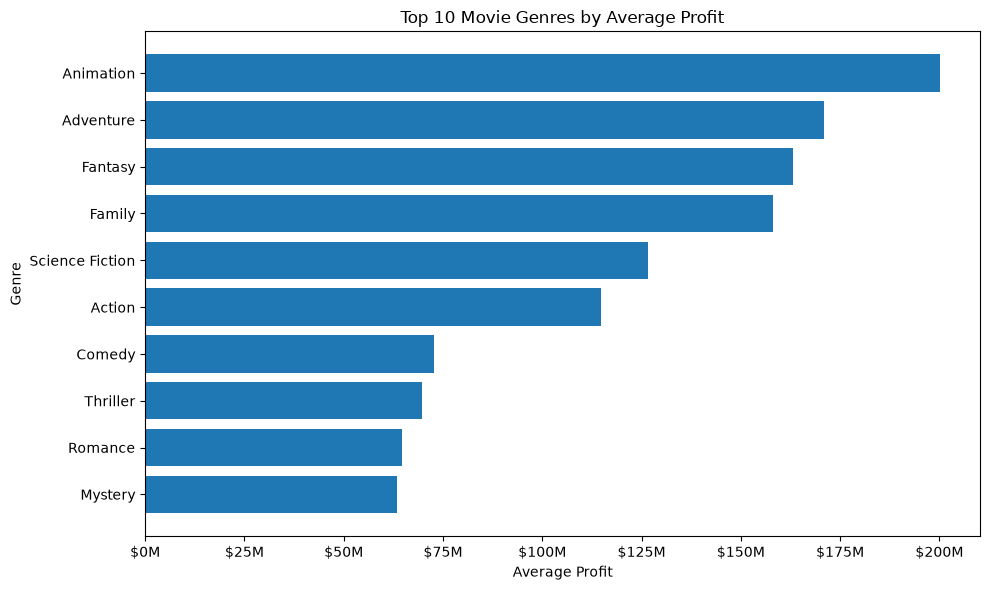

In [40]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

top_genres = (
    genre_performance
    .sort_values("average_profit", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_genres.index,
    top_genres["average_profit"]
)

plt.xlabel("Average Profit")
plt.ylabel("Genre")
plt.title("Top 10 Movie Genres by Average Profit")

# Show values as $50M, $100M, etc.
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x/1_000_000:.0f}M")
)

plt.gca().invert_yaxis()
plt.tight_layout()

# Save the chart
plt.savefig(
    "../visuals/top_genres_average_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

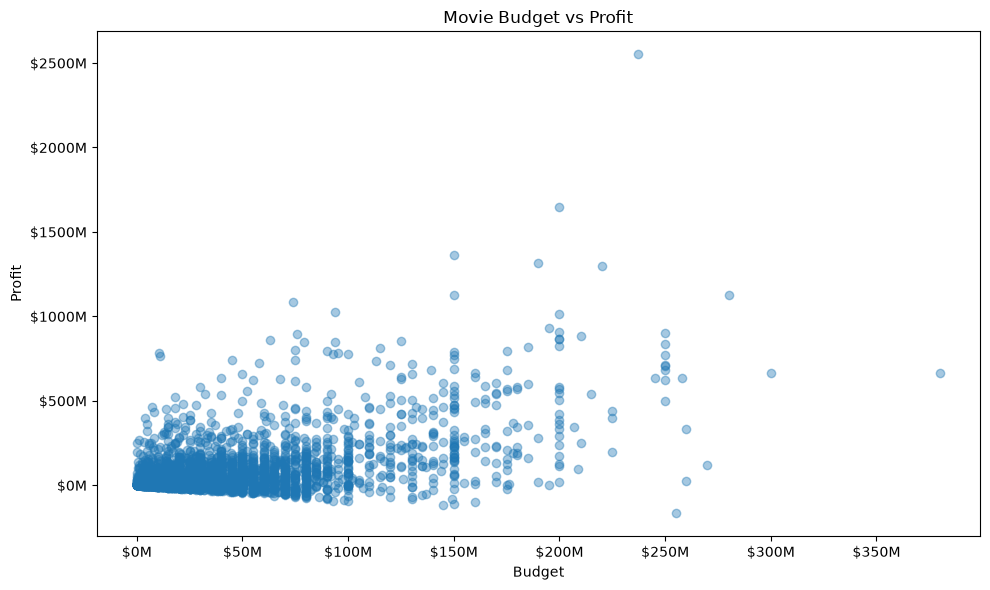

In [41]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 6))

plt.scatter(
    financial_movies["budget"],
    financial_movies["profit"],
    alpha=0.4
)

plt.xlabel("Budget")
plt.ylabel("Profit")
plt.title("Movie Budget vs Profit")

ax = plt.gca()

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x/1_000_000:.0f}M")
)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x/1_000_000:.0f}M")
)

plt.tight_layout()

plt.savefig(
    "../visuals/budget_vs_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

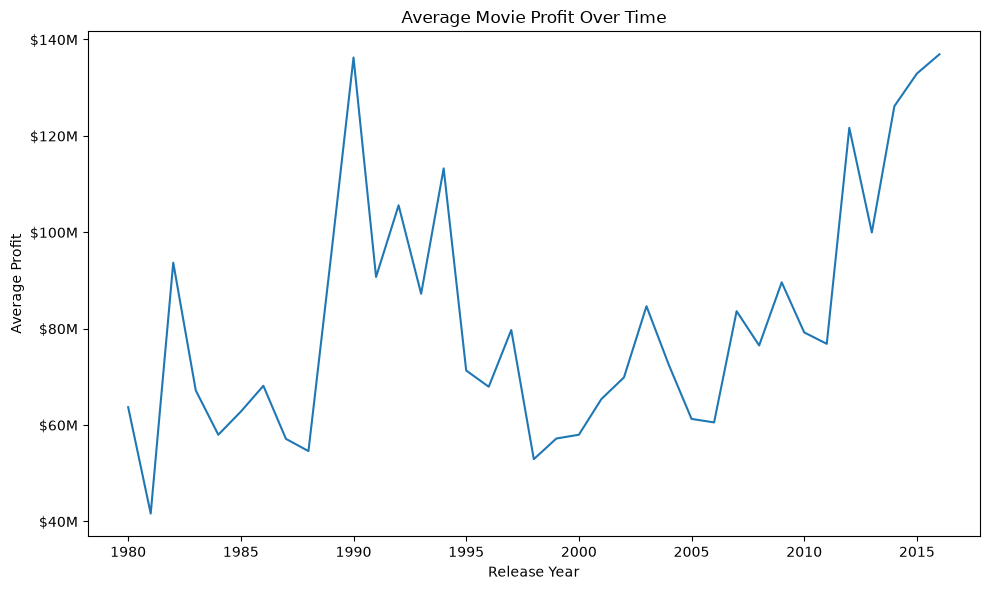

In [42]:
yearly_performance = (
    financial_movies[
        financial_movies["release_year"].notna()
        & (financial_movies["release_year"] >= 1980)
    ]
    .groupby("release_year")
    .agg(
        average_profit=("profit", "mean"),
        average_revenue=("revenue", "mean"),
        movie_count=("title", "count")
    )
    .reset_index()
)

yearly_performance = yearly_performance[
    yearly_performance["movie_count"] >= 10
]

plt.figure(figsize=(10, 6))

plt.plot(
    yearly_performance["release_year"],
    yearly_performance["average_profit"]
)

plt.xlabel("Release Year")
plt.ylabel("Average Profit")
plt.title("Average Movie Profit Over Time")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x/1_000_000:.0f}M")
)

plt.tight_layout()

plt.savefig(
    "../visuals/average_profit_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

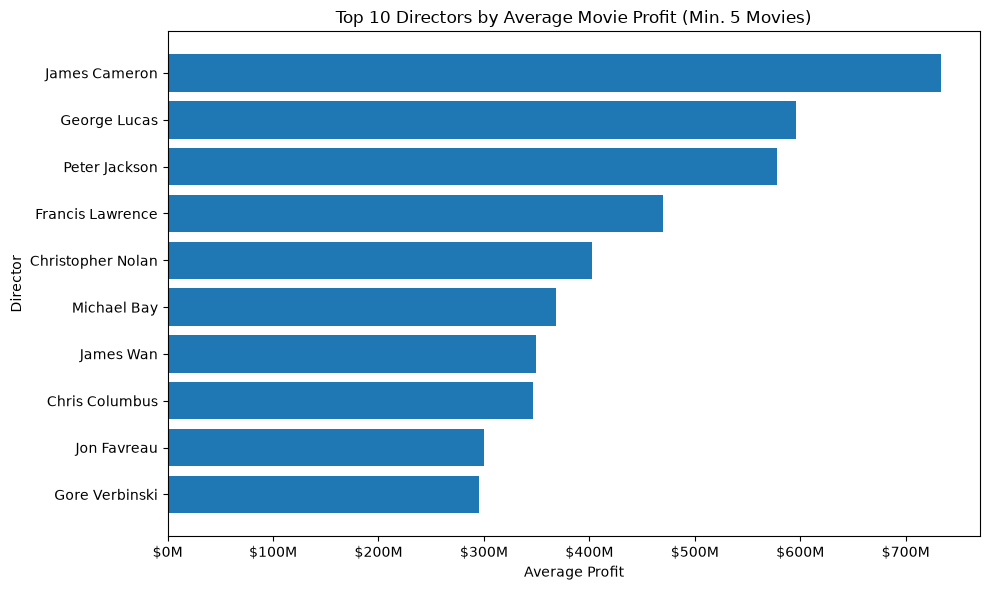

In [43]:
top_directors = (
    director_performance[
        director_performance["movie_count"] >= 5
    ]
    .sort_values("average_profit", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_directors.index,
    top_directors["average_profit"]
)

plt.xlabel("Average Profit")
plt.ylabel("Director")
plt.title("Top 10 Directors by Average Movie Profit (Min. 5 Movies)")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x/1_000_000:.0f}M")
)

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    "../visuals/top_directors_average_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Load cleaned data
df = pd.read_csv("../data/movies_analysis_cleaned.csv")

# Keep valid financial data
rating_data = df[
    (df["budget"] > 0) &
    (df["revenue"] > 0) &
    (df["vote_average"].notna())
].copy()

# Calculate profit
rating_data["profit"] = rating_data["revenue"] - rating_data["budget"]

# Create rating categories
rating_data["rating_category"] = pd.cut(
    rating_data["vote_average"],
    bins=[0, 5, 6, 7, 8, 10],
    labels=["Below 5", "5-6", "6-7", "7-8", "8+"],
    include_lowest=True
)

# Average profit by rating
rating_plot = (
    rating_data.groupby("rating_category", observed=True)["profit"]
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(9, 6))

plt.bar(
    rating_plot["rating_category"].astype(str),
    rating_plot["profit"]
)

plt.xlabel("Rating Category")
plt.ylabel("Average Profit")
plt.title("Average Movie Profit by Rating Category")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x/1_000_000:.0f}M")
)

plt.tight_layout()

plt.savefig(
    "../visuals/rating_vs_average_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

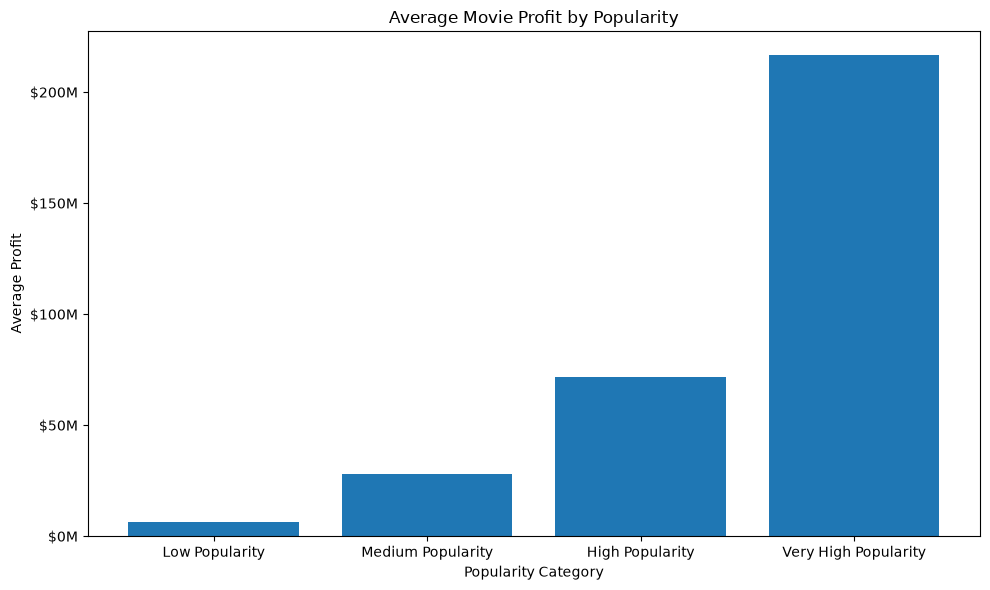

In [ ]:
# Popularity vs Average Profit

popularity_data = df[
    (df["budget"] > 0) &
    (df["revenue"] > 0) &
    (df["popularity"].notna())
].copy()

popularity_data["profit"] = (
    popularity_data["revenue"] - popularity_data["budget"]
)

# Divide movies into 4 popularity groups
popularity_data["popularity_category"] = pd.qcut(
    popularity_data["popularity"],
    q=4,
    labels=[
        "Low Popularity",
        "Medium Popularity",
        "High Popularity",
        "Very High Popularity"
    ]
)

popularity_plot = (
    popularity_data
    .groupby("popularity_category", observed=True)["profit"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.bar(
    popularity_plot["popularity_category"].astype(str),
    popularity_plot["profit"]
)

plt.xlabel("Popularity Category")
plt.ylabel("Average Profit")
plt.title("Average Movie Profit by Popularity")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x/1_000_000:.0f}M")
)

plt.tight_layout()

plt.savefig(
    "../visuals/popularity_vs_average_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 7. Key Insights

The analysis identified several important patterns in movie performance:

- **Animation, Adventure, Fantasy, and Family** were among the genres with the highest average profits.
- Higher production budgets were generally associated with higher profits, although a larger budget did not guarantee financial success.
- Movies with stronger audience ratings showed substantially higher average profits. Movies rated **8+** generated an average profit of approximately **$200M**, compared with much lower profits among poorly rated movies.
- Popularity showed a strong positive association with financial performance. Movies in the **Very High Popularity** category generated substantially higher average profits than less popular movies.
- Among directors with at least five movies in the dataset, **James Cameron** recorded the highest average profit, followed by **George Lucas** and **Peter Jackson**.
- Movie profitability generally increased over time, although performance varied considerably from year to year.
- ROI should be interpreted carefully because extremely low-budget movies can produce unusually large ROI values even when their absolute profits are much smaller.

### Business Takeaway

For a movie studio, the results suggest that commercial success is associated with a combination of genre selection, audience reception, popularity, and effective budget allocation rather than budget size alone. Historical director performance can also provide useful context when evaluating potential projects.

These findings represent patterns and associations within the analyzed dataset and should not be interpreted as proof of causation.